<a href="https://colab.research.google.com/github/Roshanreddy03/Netflix-data-cleaning/blob/main/Netflix_titles_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data cleaning

Load the dataset using pandas

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("EDA_netflix.db")

df = pd.read_csv("netflix_titles.csv")
df.to_sql("netflix_titles", conn, if_exists="replace", index=False)

print("Table created successfully !")

Table created successfully !


In [3]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Core Data Cleaning**

1. Handling Missing Values

In [8]:
# Fill missing text data with "Unknown" using direct assignment
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows where 'date_added' and 'rating' are missing
df.dropna(subset=['date_added', 'rating'], inplace=True)

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


2. Fixing the Mixed-Type duration Column

In [9]:
# Add an 'r' before the string to make it a raw string
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Let's see how it looks alongside the original column and the 'type' column
df[['title', 'type', 'duration', 'duration_num']].head()

,title,type,duration,duration_num
0,Dick Johnson Is Dead,Movie,90 min,90.0
1,Blood & Water,TV Show,2 Seasons,2.0
2,Ganglands,TV Show,1 Season,1.0
3,Jailbirds New Orleans,TV Show,1 Season,1.0
4,Kota Factory,TV Show,2 Seasons,2.0


3. Parsing the Date Column

In [10]:
# Added .astype(str) to force it into text first
df['duration_num'] = df['duration'].astype(str).str.extract(r'(\d+)').astype(float)

In [11]:
# Added .astype(str) to force it into text first
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')

Exporting the clean data

In [17]:
# Export the cleaned DataFrame to a new CSV file
df.to_csv('netflix_cleaned.csv', index=False)

print("Data cleaning completed!\n File saved successfully.")

Data cleaning completed!
 File saved successfully.


# Netflix graphs

1. Basic Counts (What type of content is there?)


   Graph: Bar Plot of Movies vs. TV Shows

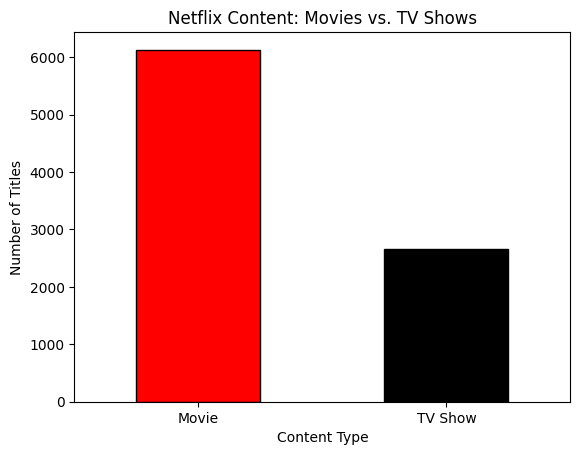

In [13]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

type_counts.plot(kind='bar', color=['red', 'black'], edgecolor='black')
plt.title('Netflix Content: Movies vs. TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.show()

2. Continuous Variables (How old is the content?)

   Graph: Histogram of Release Years

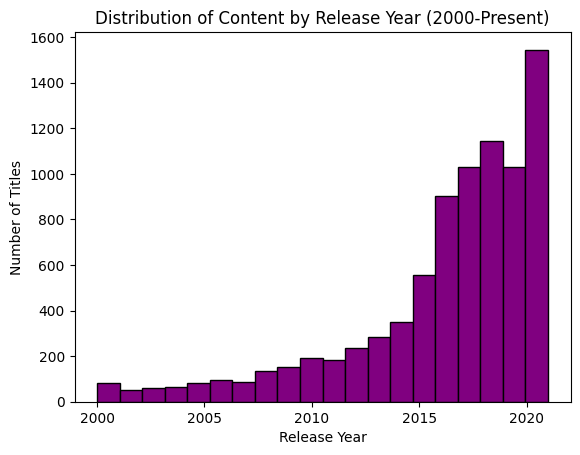

In [14]:
# Filtering for years after 2000 to keep the graph focused and readable
recent_content = df[df['release_year'] >= 2000]

plt.hist(recent_content['release_year'].dropna(), bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Content by Release Year (2000-Present)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

3. Categorical Variables (Where is content made?)

   Graph: Horizontal Bar Plot of Top 5 Countries

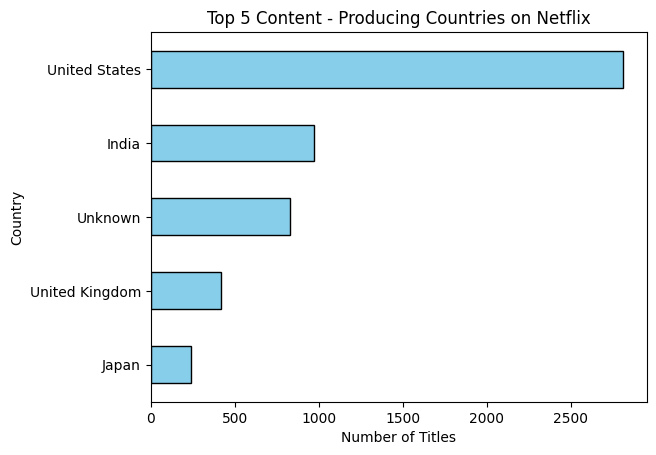

In [19]:
# Grabbing just the top 5 to keep the chart clean
top_countries = df['country'].value_counts().head(5)

top_countries.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 5 Content - Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.gca().invert_yaxis() # Flips the chart so the #1 country is at the very top
plt.show()